<a href="https://colab.research.google.com/github/arrietagustavo723-cyber/Mi_Negocio/blob/main/G203008067_1_Gustavo_Arrieta_Tarea2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://www.unad.edu.co/images/footer/logo-unad-acreditacion-min.png" width="780" height="140" align="right"/>

# Fase 3 – Componente práctico – Prácticas simuladas
## Plantilla de trabajo – Modelos de *Aprendizaje supervisado* (Modelos de regresión y clasificación)

**Curso:** Machine Learning – Componente práctico
**Estudiante:** Gustavo Adolfo Arrieta García
**Código:** 203008067
**Grupo:** 203008067_1
**Ítem / Literal trabajado:** E
**Fecha:** 04/10/2026

---

**Datasets del ítem E**

| Uso | Dataset | ID OpenML |
|-----|---------|-----------|
| Regresión | CPMP-2015-regression | 41700 |
| Clasificación | climate-model-simulation-crashes | 1467 |

**Recomendaciones generales**

- Este archivo es de uso **personal**. El desarrollo debe ser producto de su propio trabajo.
- Según el Acuerdo 029 de 2013, el **fraude académico y el plagio** se sancionan con **calificación 0**.
- Las explicaciones e interpretaciones deben estar redactadas **con sus propias palabras**.
- Nombre de entrega: `G#_Nombre_Apellido_Tarea2.ipynb`.

---


# Importación de librerías

Se importan las librerías necesarias para el análisis de datos, las visualizaciones y los modelos de
aprendizaje supervisado. Se fija una semilla (`RANDOM_STATE = 42`) para que todos los resultados sean
**reproducibles**.

In [4]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


# Importación dataset

- **Regresión:** `CPMP-2015-regression` (ID 41700).
- **Clasificación:** `climate-model-simulation-crashes` (ID 1467).

In [5]:
dfr = fetch_openml(data_id=41700, parser='auto', as_frame=True)  # regresión
dfc = fetch_openml(data_id=1467, parser='auto', as_frame=True)   # clasificación

Xr = dfr.data.copy()                 # características regresión
yr = pd.to_numeric(dfr.target, errors='coerce')   # variable objetivo regresión (runtime)

Xc = dfc.data.copy()                 # características clasificación
yc_raw = dfc.target                  # variable objetivo clasificación (clase 1/2)

# Copias originales (para las gráficas que necesitan columnas antes de transformar)
Xr_original = dfr.data.copy()

print('Regresión  -> X:', Xr.shape, '| target:', yr.name)
print('Clasificación -> X:', Xc.shape, '| target:', yc_raw.name)

Regresión  -> X: (2108, 26) | target: runtime
Clasificación -> X: (540, 20) | target: Class


# Ejercicio 1: Contextualización Dataset.

## Dataset de regresión: CPMP-2015-regression (ID 41700)

- **Contexto.** Corresponde a un *benchmark de selección de algoritmos* para el problema de
  **reordenamiento previo de contenedores** (*Container Pre-Marshalling Problem*, CPMP). En los patios
  de contenedores, los bloques se apilan y a veces es necesario reubicar contenedores para poder
  retirar uno que quedó bloqueado. Existen varios algoritmos que resuelven el problema y su
  desempeño depende de las características de cada instancia. El dataset describe instancias del
  problema mediante un conjunto de *features* y registra, para cada par (instancia, algoritmo), el
  **tiempo de ejecución** del algoritmo. El propósito es predecir ese tiempo a partir de las
  características de la instancia y del algoritmo utilizado.
- **Tamaño.** 2.108 registros y 27 columnas (25 de características más la variable objetivo y un
  identificador). Tras el preprocesamiento (ver Ejercicio 2) quedan 1.526 registros.
- **Variable objetivo.** `runtime`: tiempo de ejecución del algoritmo (variable continua, en
  segundos). Es una variable **sesgada hacia la derecha** y con valores censurados (ver más abajo).
- **Variables asociadas.** Características de la instancia como `stacks` (número de pilas),
  `tiers` (niveles), `container.density` (densidad de ocupación), `empty.stack.pct` (porcentaje de
  pilas vacías), `overstowage.pct` (porcentaje de bloqueos), `top.good.mean`, `stack.tier.ratio`,
  `bflb`, etc., además de la variable categórica `algorithm` (algoritmo usado) y `runstatus`
  (estado de la corrida: `ok`, `timeout`, `memout`).

## Dataset de clasificación: climate-model-simulation-crashes (ID 1467)

- **Contexto.** Proviene de un experimento del *Lawrence Livermore National Laboratory*. Se ejecutó
  repetidamente una simulación climática variando 18 parámetros inciertos y se registró si la
  simulación **terminaba con éxito o se colapsaba** (*crash*). El objetivo es predecir el colapso a
  partir de combinaciones de parámetros, un problema clásico de detección de fallos.
- **Tamaño.** 540 registros y 21 columnas (20 variables numéricas `V1`…`V20` más la clase).
- **Variable objetivo.** `Class`: indica si la simulación colapsó. La etiqueta original es
  `{1, 2}`; se codifica como **1 = crash** (clase minoritaria, 46 casos) y **0 = no crash**
  (494 casos).
- **Variables asociadas.** Las 20 variables numéricas `V1`…`V20` representan parámetros de la
  simulación, normalizados en el intervalo [0, 1]. El problema está **fuertemente desbalanceado**.


# Ejercicio 2: Análisis cuantitativo y cualitativo.

## 2.1 Exploración inicial y calidad de los datos

In [6]:
print('=' * 70)
print('EXPLORACIÓN - REGRESIÓN: CPMP-2015-regression')
print('=' * 70)
print('Dimensiones:', Xr.shape)
print('\nTipos de datos:\n', Xr.dtypes.value_counts())
print('\nValores nulos totales:', int(Xr.isnull().sum().sum()))
print('Registros duplicados:', int(Xr.duplicated().sum()))
print('\nrunstatus:', Xr['runstatus'].value_counts().to_dict())
print('algorithm :', Xr['algorithm'].value_counts().to_dict())
display(Xr.describe().T)

EXPLORACIÓN - REGRESIÓN: CPMP-2015-regression
Dimensiones: (2108, 26)

Tipos de datos:
 float64     15
int64        8
object       1
category     1
category     1
Name: count, dtype: int64

Valores nulos totales: 0
Registros duplicados: 0

runstatus: {'ok': 1526, 'memout': 371, 'timeout': 211}
algorithm : {'astar.symmulgt.transmul': 527, 'astar.symmullt.transmul': 527, 'idastar.symmulgt.transmul': 527, 'idastar.symmullt.transmul': 527}


,count,mean,std,min,25%,50%,75%,max
repetition,2108.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
stacks,2108.0,11.548387,5.986937,4.000000,6.000000,12.000000,16.000000,20.000000
tiers,2108.0,5.874763,0.911597,5.000000,5.000000,6.000000,7.000000,8.000000
stack.tier.ratio,2108.0,0.736708,0.478441,0.250000,0.312500,0.500000,1.000000,1.750000
container.density,2108.0,0.681446,0.069840,0.600000,0.600000,0.666667,0.714286,0.800000
empty.stack.pct,2108.0,0.065979,0.111322,0.000000,0.000000,0.000000,0.100000,0.400000
overstowing.stack.pct,2108.0,0.850599,0.155872,0.500000,0.714286,0.875000,1.000000,1.000000
overstowing.2cont.stack.pct,2108.0,0.953640,0.079766,0.583333,0.923077,1.000000,1.000000,1.000000
group.same.min,2108.0,0.493359,0.500075,0.000000,0.000000,0.000000,1.000000,1.000000
group.same.max,2108.0,3.658444,2.898871,1.000000,1.000000,4.000000,6.000000,14.000000


In [7]:
print('=' * 70)
print('EXPLORACIÓN - CLASIFICACIÓN: climate-model-simulation-crashes')
print('=' * 70)
print('Dimensiones:', Xc.shape)
print('\nTipos de datos:\n', Xc.dtypes.value_counts())
print('\nValores nulos totales:', int(Xc.isnull().sum().sum()))
print('Registros duplicados:', int(Xc.duplicated().sum()))
print('\nConteo de clases (original):', yc_raw.value_counts().to_dict())
display(Xc.describe().T)

EXPLORACIÓN - CLASIFICACIÓN: climate-model-simulation-crashes
Dimensiones: (540, 20)

Tipos de datos:
 float64    17
int64       3
Name: count, dtype: int64

Valores nulos totales: 0
Registros duplicados: 0

Conteo de clases (original): {'2': 494, '1': 46}


,count,mean,std,min,25%,50%,75%,max
V1,540.0,2.000000,0.817254,1.000000,1.000000,2.000000,3.000000,3.000000
V2,540.0,90.500000,52.008901,1.000000,45.750000,90.500000,135.250000,180.000000
V3,540.0,270.500000,156.028843,1.000000,135.750000,270.500000,405.250000,540.000000
V4,540.0,0.500096,0.288922,0.001922,0.251597,0.499595,0.750011,0.998815
V5,540.0,0.500027,0.289067,0.001181,0.251540,0.500104,0.749180,0.998263
V6,540.0,0.500119,0.288993,0.001972,0.250159,0.500456,0.750348,0.997673
V7,540.0,0.500001,0.288827,0.000858,0.250630,0.500903,0.748988,0.998944
V8,540.0,0.499913,0.288852,0.000476,0.251325,0.499174,0.748166,0.997142
V9,540.0,0.500059,0.289010,0.004590,0.253047,0.499070,0.750108,0.998930
V10,540.0,0.500076,0.288909,0.000296,0.250402,0.500074,0.749091,0.998506


**Interpretación de la exploración.**
Ninguno de los dos datasets presenta valores nulos ni registros duplicados, lo que simplifica la
limpieza. En la regresión aparecen columnas de distinto tipo: `instance_id` es un identificador (texto),
`algorithm` y `runstatus` son categóricas, y el resto son numéricas. En la clasificación todas las
variables son numéricas en el rango [0, 1] y la clase está desbalanceada (494 casos "no crash" frente
a solo 46 "crash", un 8,5 % de la clase positiva).

## Preprocesamiento de datos (decisiones documentadas)

**Regresión.**
1. Se elimina `instance_id` porque es un **identificador** sin valor predictivo.
2. Se elimina la columna constante `repetition` (tiene un único valor → no aporta información).
3. **Tratamiento de valores censurados.** Las corridas con `runstatus` igual a `timeout` o `memout`
   registran `runtime = 3600 s`, que **no es el tiempo real** de ejecución sino el límite impuesto
   ("techo") al experimento. Se trata de observaciones **censuradas**, no de mediciones reales. Por
   eso se **excluyen** (582 filas) para no sesgar el modelo. *Justificación:* incluir un valor
   artificial repetido de 3600 s introduce un patrón que el modelo intentaría aprender y que no
   refleja el fenómeno. Es una decisión de calidad de datos, no una eliminación arbitraria.
4. Se codifica la variable categórica `algorithm` con *one-hot encoding*.
5. La columna `runstatus` **no se usa como predictor** (define el tope de 3600 s y generaría fuga de
   información); solo se usó para filtrar.
6. La variable objetivo `runtime` está muy sesgada hacia la derecha, por lo que se transforma con
   **log1p**. Esto estabiliza la varianza y mejora el ajuste de los modelos. *Consecuencia:* las
   métricas MSE/MAE/RMSE quedan expresadas en unidades de `log1p(segundos)`; el R² es adimensional.

**Clasificación.**
1. No hay nulos ni duplicados.
2. La variable objetivo `Class` (`{1, 2}`) se codifica como **1 = crash** y **0 = no crash**.
3. Se aplicará **estandarización** antes de los modelos sensibles a escala (regresión logística, KNN
   y MLP). El árbol de decisión no la necesita, pero se usa la misma matriz escalada para comparar
   de forma justa.

**Sobre los outliers.** El enunciado recomienda revisarlos. En la regresión, la transformación
`log1p` reduce el efecto de los runtimes extremos sin borrar observaciones. En la clasificación, las
variables están acotadas en [0, 1] por construcción, por lo que los "outliers" son valores válidos del
experimento. En ambos casos se opta por **conservar** los datos y documentar el tratamiento, en lugar
de eliminar registros sin justificación.

In [8]:
# --- Preprocesamiento REGRESIÓN ---
# 1. Eliminar identificador
Xr = Xr.drop(columns=['instance_id'])

# 2. Eliminar columnas constantes
constantes = [c for c in Xr.columns if Xr[c].nunique() <= 1]
Xr = Xr.drop(columns=constantes)
print('Columna(s) constante(s) eliminada(s):', constantes)

# 3. Excluir corridas censuradas (timeout / memout)
mask_ok = (Xr['runstatus'] == 'ok').values
print('Filas antes:', len(Xr), '| filas tras excluir censuradas:', int(mask_ok.sum()))
Xr = Xr.loc[mask_ok].drop(columns=['runstatus']).reset_index(drop=True)
yr = yr.loc[mask_ok].reset_index(drop=True)

# 4. Codificar variable categórica algorithm
Xr = pd.get_dummies(Xr, columns=['algorithm'], drop_first=True)

# 5. Transformar el target sesgado
yr_log = np.log1p(yr)

print('Forma final de X (regresión):', Xr.shape)
print('Rango del target original (s):', round(yr.min(), 3), '-', round(yr.max(), 3))
print('Rango del target log1p       :', round(yr_log.min(), 3), '-', round(yr_log.max(), 3))

Columna(s) constante(s) eliminada(s): ['repetition']
Filas antes: 2108 | filas tras excluir censuradas: 1526
Forma final de X (regresión): (1526, 25)
Rango del target original (s): 0.0 - 3588.976
Rango del target log1p       : 0.0 - 8.186


In [9]:
# --- Preprocesamiento CLASIFICACIÓN ---
# Codificar la clase: en el dataset original '1' = crash, '2' = no crash
yc = (yc_raw.astype(str) == '1').astype(int)
print('Conteo codificado:', yc.value_counts().to_dict())
print('Proporción de crash:', round(yc.mean() * 100, 2), '%')

Conteo codificado: {0: 494, 1: 46}
Proporción de crash: 8.52 %


## 2.2 Diagramas de dispersión y respectivo análisis

### Regresión
Se relacionan algunas de las variables más asociadas con el target (`log1p(runtime)`) para evaluar el
tipo de relación (lineal o no lineal).

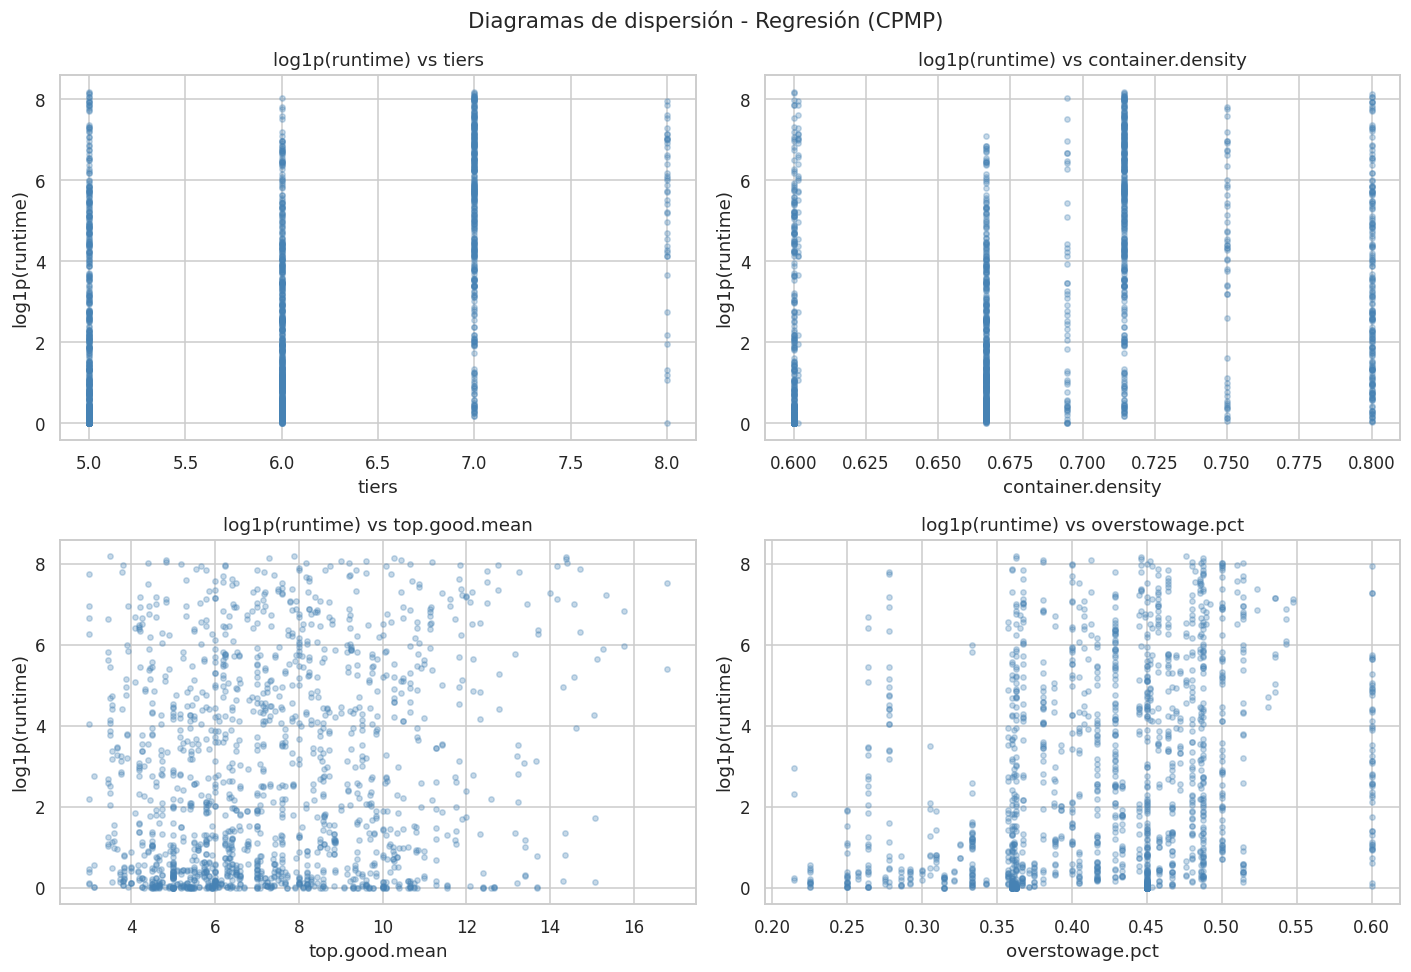

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
vars_sel = ['tiers', 'container.density', 'top.good.mean', 'overstowage.pct']
for ax, v in zip(axes.ravel(), vars_sel):
    ax.scatter(Xr[v], yr_log, alpha=0.30, s=12, color='steelblue')
    ax.set_title(f'log1p(runtime) vs {v}')
    ax.set_xlabel(v)
    ax.set_ylabel('log1p(runtime)')
plt.suptitle('Diagramas de dispersión - Regresión (CPMP)', fontsize=14)
plt.tight_layout()
plt.show()

**Análisis.** La relación entre estas variables y el tiempo de ejecución **no es lineal**: se
observa una nube con tendencia creciente (más pilas, más niveles o mayor densidad tienden a aumentar
el runtime), pero con mucha dispersión. Esto anticipa que los modelos lineales tendrán un desempeño
moderado y que modelos flexibles (árbol, red neuronal) podrían capturar mejor la no linealidad. La
transformación logarítmica comprime los valores extremos y hace la nube más legible.

### Clasificación
Se grafican dos variables en el plano y una proyección PCA de 2 componentes, coloreando por clase.

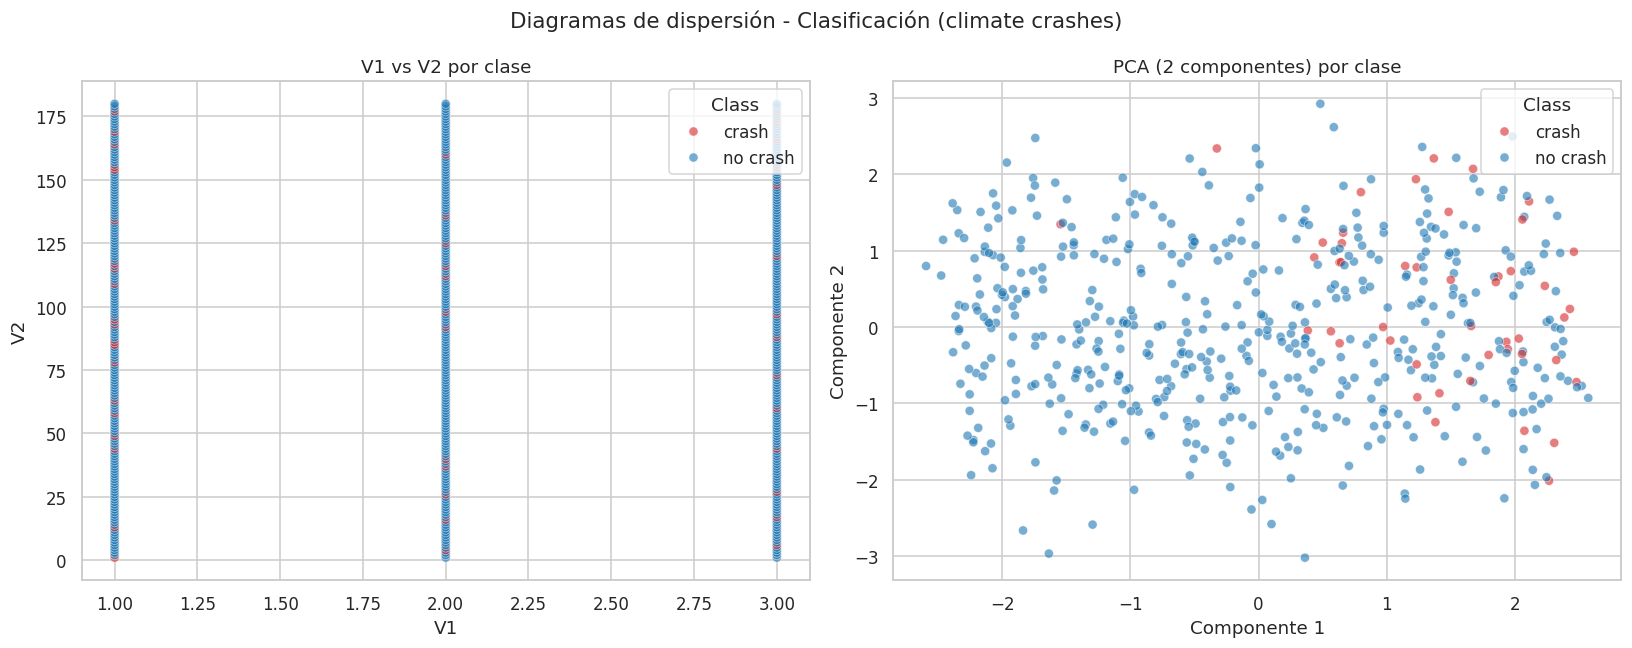

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(x=Xc['V1'], y=Xc['V2'], hue=yc.map({0: 'no crash', 1: 'crash'}),
                alpha=0.6, ax=axes[0], palette={'no crash': 'tab:blue', 'crash': 'tab:red'})
axes[0].set_title('V1 vs V2 por clase')

Xc_std = StandardScaler().fit_transform(Xc)
comp = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(Xc_std)
sns.scatterplot(x=comp[:, 0], y=comp[:, 1], hue=yc.map({0: 'no crash', 1: 'crash'}),
                alpha=0.6, ax=axes[1], palette={'no crash': 'tab:blue', 'crash': 'tab:red'})
axes[1].set_title('PCA (2 componentes) por clase')
axes[1].set_xlabel('Componente 1'); axes[1].set_ylabel('Componente 2')

plt.suptitle('Diagramas de dispersión - Clasificación (climate crashes)', fontsize=14)
plt.tight_layout()
plt.show()

**Análisis.** En V1 vs V2 las dos clases se **solapan fuertemente**: no existe una frontera simple
que las separe. En la proyección PCA ocurre algo similar, con los pocos casos de *crash* (rojo)
mezclados entre los de *no crash* (azul). Esto sugiere que el problema de clasificación es **difícil**
y que el fuerte desbalance de clases jugará un papel importante en las métricas.

## 2.3 Diagramas de barras y respectivo análisis

### Regresión

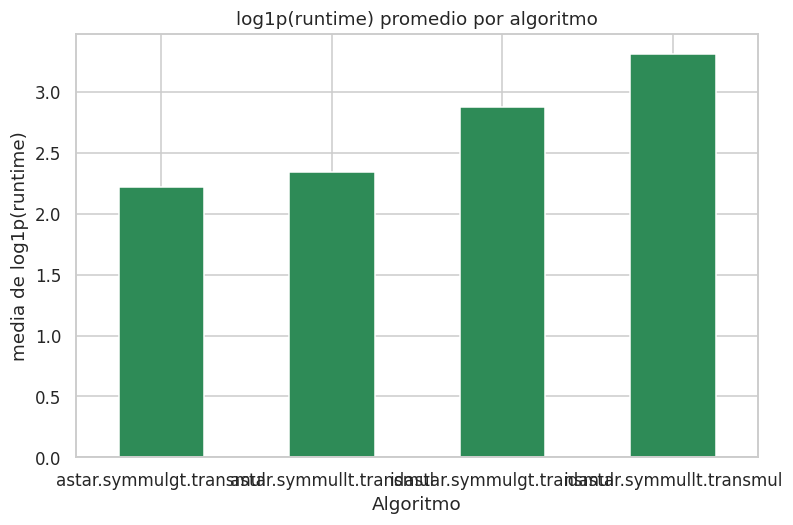

algorithm
astar.symmulgt.transmul      2.222
astar.symmullt.transmul      2.346
idastar.symmulgt.transmul    2.879
idastar.symmullt.transmul    3.312
Name: runtime, dtype: float64


In [12]:
tmp = Xr_original.copy()
tmp['runtime'] = pd.to_numeric(dfr.target, errors='coerce')
tmp = tmp[tmp['runstatus'] == 'ok']

media_log = tmp.groupby('algorithm')['runtime'].apply(lambda s: np.log1p(s).mean()).sort_values()
ax = media_log.plot(kind='bar', color='seagreen')
ax.set_title('log1p(runtime) promedio por algoritmo')
ax.set_xlabel('Algoritmo'); ax.set_ylabel('media de log1p(runtime)')
plt.xticks(rotation=0)
plt.show()
print(media_log.round(3))

**Análisis.** Se observa que el tiempo de ejecución **depende del algoritmo**. Algunos algoritmos
tardan sistemáticamente más que otros, lo que confirma que `algorithm` es una variable asociada
relevante. Por eso se conserva codificada como predictor.

### Clasificación

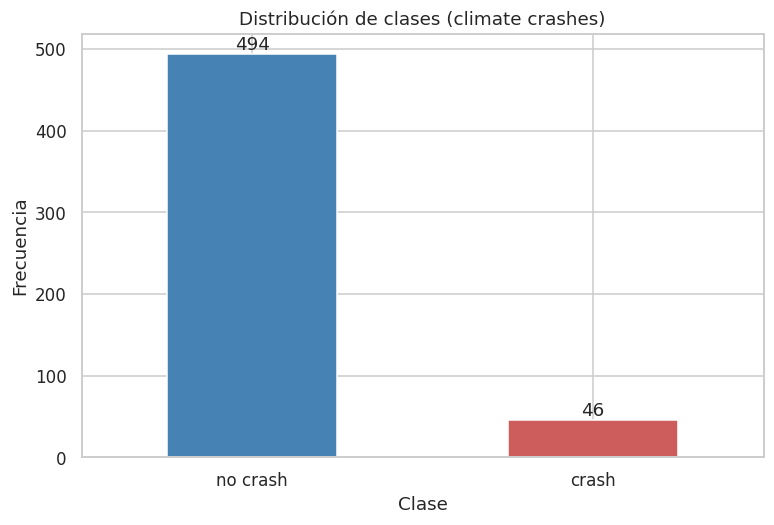

In [13]:
conteo = yc.map({0: 'no crash', 1: 'crash'}).value_counts()
ax = conteo.plot(kind='bar', color=['steelblue', 'indianred'])
ax.set_title('Distribución de clases (climate crashes)')
ax.set_xlabel('Clase'); ax.set_ylabel('Frecuencia')
plt.xticks(rotation=0)
for i, v in enumerate(conteo.values):
    ax.text(i, v + 5, str(v), ha='center')
plt.show()

**Análisis.** El diagrama confirma el **desbalance**: 494 casos "no crash" frente a 46 "crash".
Esto implica que un modelo que prediga siempre "no crash" tendría ~91 % de accuracy pero **0 % de
recall** en la clase de interés. Por eso la interpretación debe apoyarse en precisión, recall y
F1-score, y no solo en la exactitud.

## 2.4 Boxplots y respectivo análisis

### Regresión

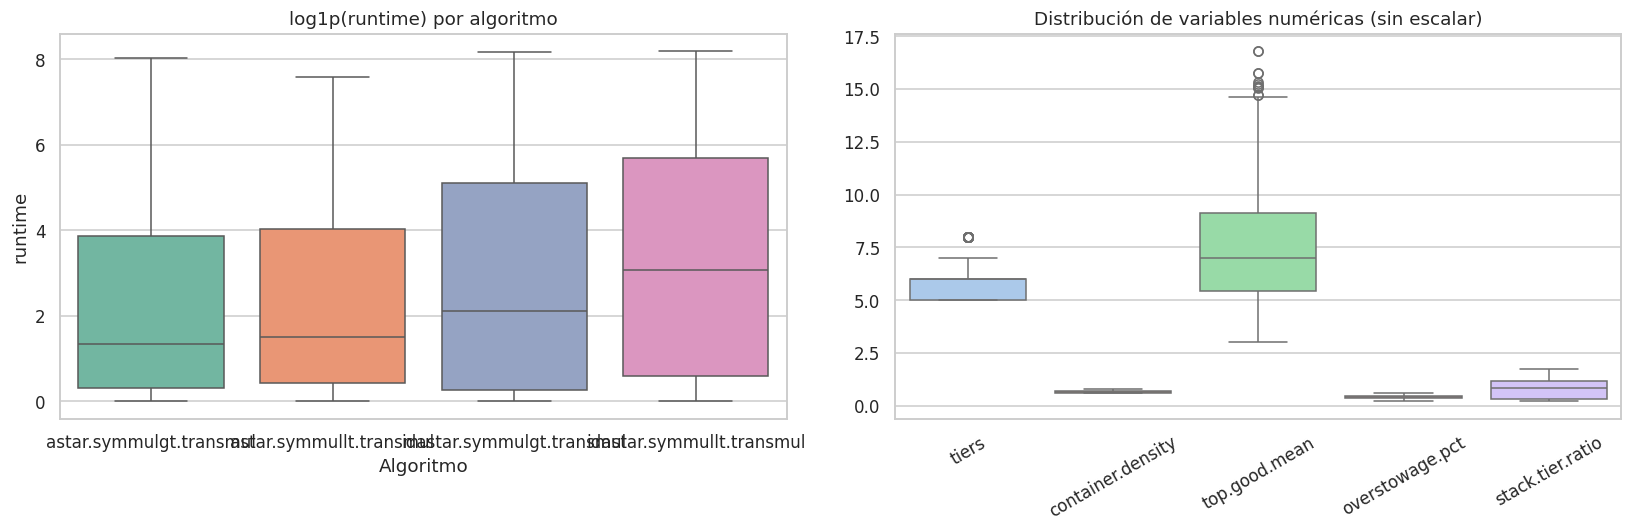

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x=tmp['algorithm'], y=np.log1p(tmp['runtime']), ax=axes[0], palette='Set2')
axes[0].set_title('log1p(runtime) por algoritmo')
axes[0].set_xlabel('Algoritmo')

vars_box = ['tiers', 'container.density', 'top.good.mean', 'overstowage.pct', 'stack.tier.ratio']
sns.boxplot(data=Xr[vars_box], ax=axes[1], palette='pastel')
axes[1].set_title('Distribución de variables numéricas (sin escalar)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Análisis.** Los boxplots por algoritmo muestran diferencias en la mediana y en la dispersión del
runtime, reforzando que el algoritmo influye. Los boxplots de las variables numéricas evidencian
**escalas muy distintas** y presencia de valores alejados (puntos fuera de los bigotes). Como se
conservan esos valores, la **estandarización** es necesaria antes de modelos sensibles a escala.

### Clasificación

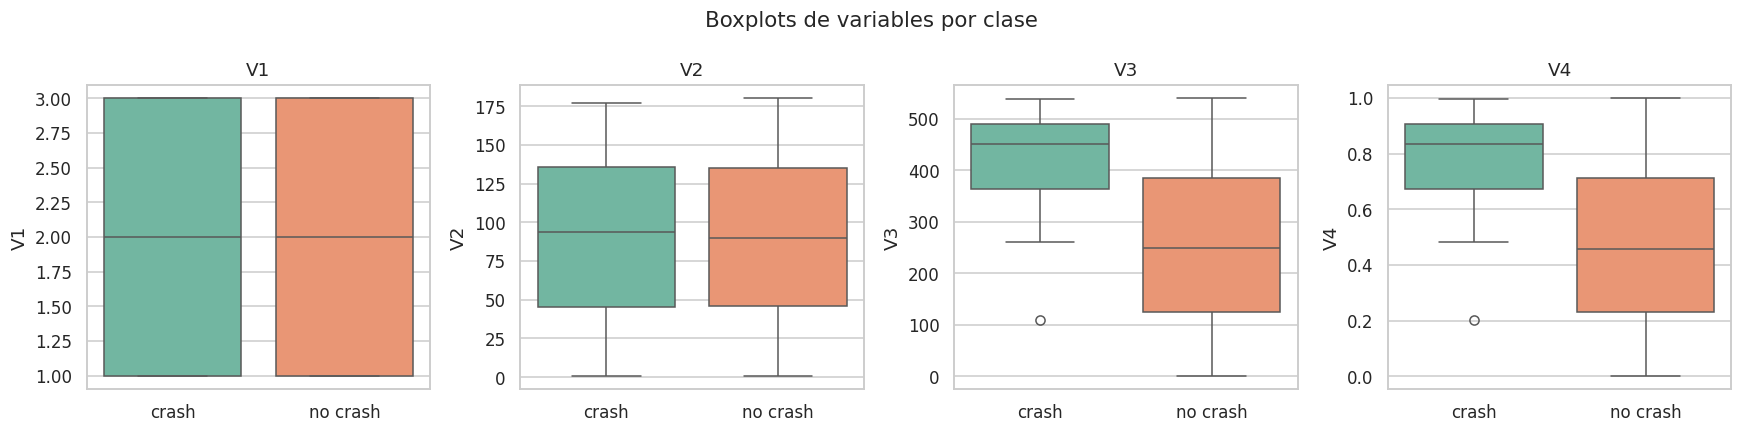

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, v in zip(axes, ['V1', 'V2', 'V3', 'V4']):
    sns.boxplot(x=yc.map({0: 'no crash', 1: 'crash'}), y=Xc[v], ax=ax, palette='Set2')
    ax.set_title(v)
    ax.set_xlabel('')
plt.suptitle('Boxplots de variables por clase', fontsize=14)
plt.tight_layout()
plt.show()

**Análisis.** Para estas variables los diagramas de caja de ambas clases se **superponen** casi
por completo, lo que confirma visualmente el solapamiento visto en la dispersión. Las variables
individualmente no separan bien las clases, de modo que el modelo deberá combinar varias de ellas.

## 2.5 Matriz de correlaciones (Heatmap) y respectivo análisis

### Regresión

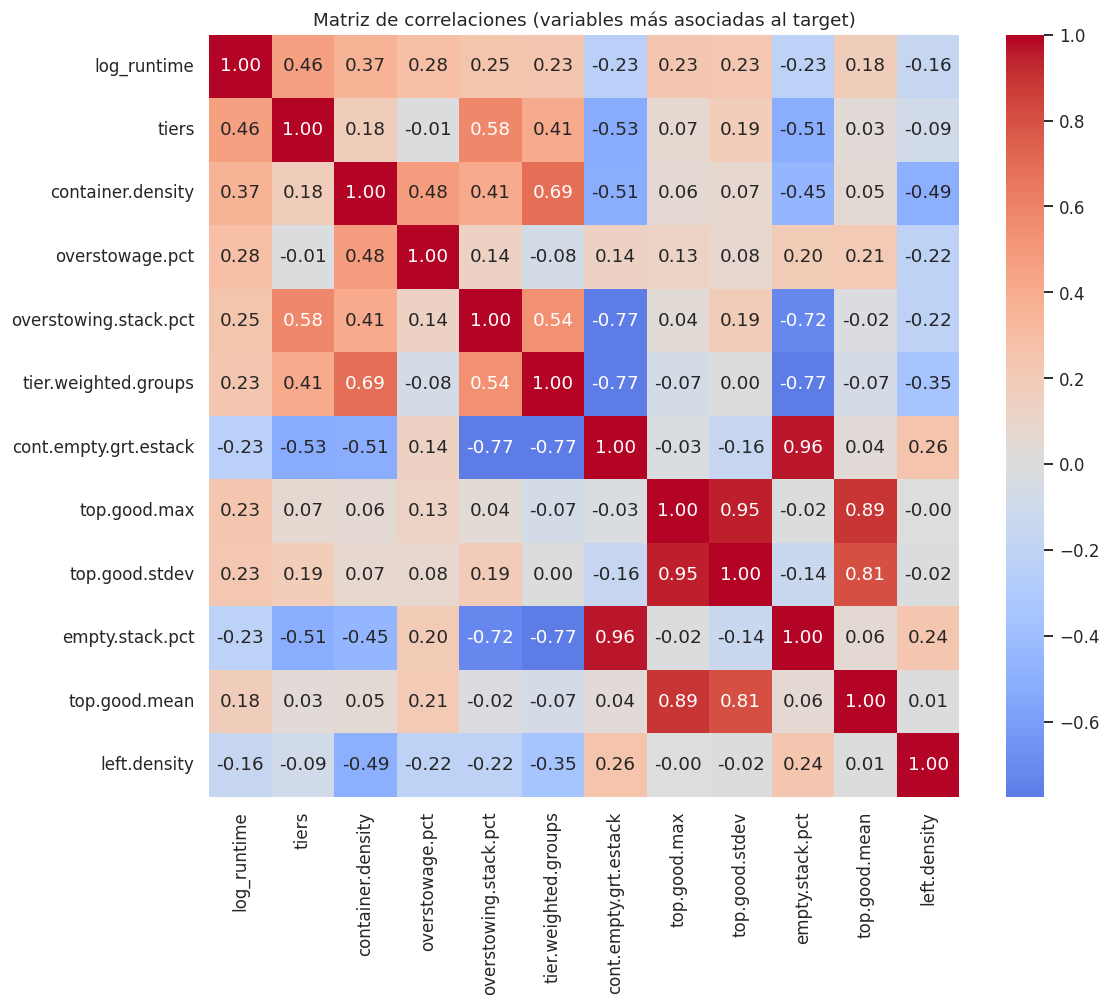

In [16]:
df_corr = Xr.copy()
df_corr['log_runtime'] = yr_log
top_corr = df_corr.corr()['log_runtime'].abs().sort_values(ascending=False).head(12).index

plt.figure(figsize=(11, 9))
sns.heatmap(df_corr[top_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlaciones (variables más asociadas al target)')
plt.show()

**Análisis.** Las correlaciones con el target son **moderadas** (ninguna supera ~0,5), lo que
explica que el R² de los modelos sea intermedio y no cercano a 1. También se observan correlaciones
apreciables **entre predictores** (algunas variables describen aspectos parecidos de la instancia), lo
que justifica el uso de regularización (Ridge/Lasso) para controlar la multicolinealidad.

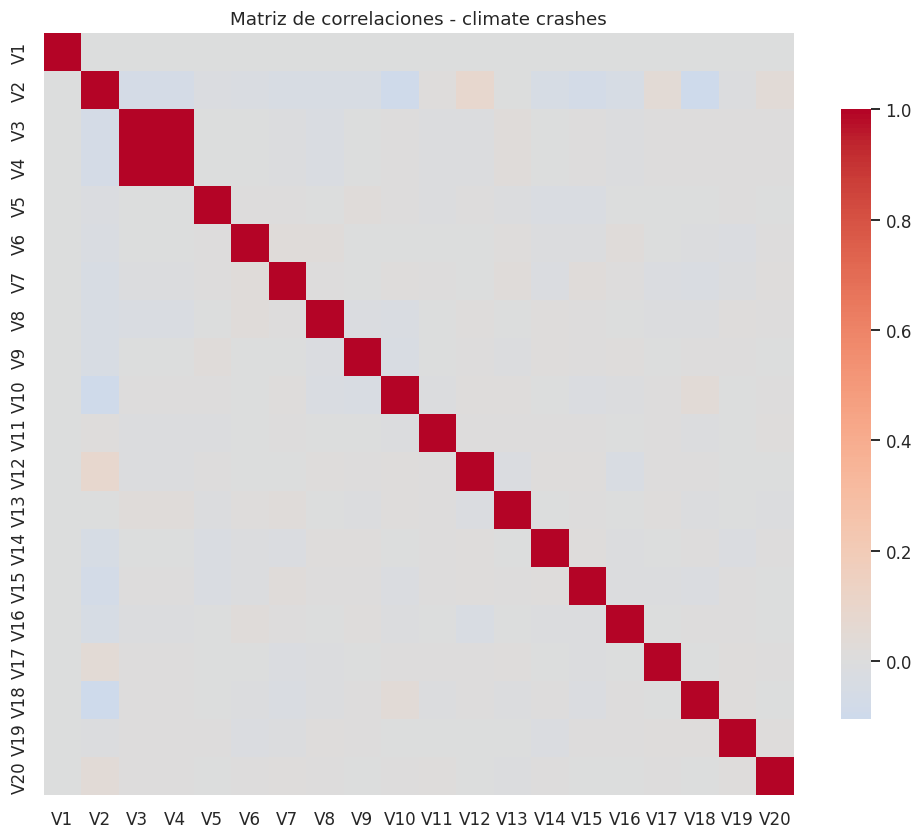

In [17]:
plt.figure(figsize=(11, 9))
sns.heatmap(Xc.corr(), cmap='coolwarm', center=0, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlaciones - climate crashes')
plt.show()

**Análisis.** En el dataset de clasificación las correlaciones entre variables son bajas en general,
por lo que los predictores aportan información relativamente independiente. No se detectan pares con
correlación cercana a 1 que obliguen a eliminar variables.

## 2.6 Tabla de contingencia y respectivo análisis

### Clasificación
Se binariza la variable `V1` por su mediana y se cruza con la clase para analizar la asociación.

Class,crash,no crash,All
V1,,,
V1 bajo,32,328,360
V1 alto,14,166,180
All,46,494,540


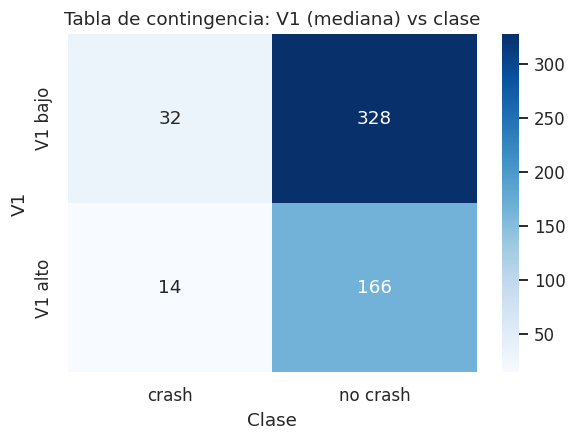

In [18]:
V1_bin = pd.cut(Xc['V1'], bins=[-np.inf, Xc['V1'].median(), np.inf], labels=['V1 bajo', 'V1 alto'])
tabla = pd.crosstab(V1_bin, yc.map({0: 'no crash', 1: 'crash'}), margins=True)
display(tabla)

plt.figure(figsize=(6, 4))
sns.heatmap(pd.crosstab(V1_bin, yc.map({0: 'no crash', 1: 'crash'})),
            annot=True, fmt='d', cmap='Blues')
plt.title('Tabla de contingencia: V1 (mediana) vs clase')
plt.ylabel('V1'); plt.xlabel('Clase')
plt.show()

**Análisis.** La tabla de contingencia muestra que la proporción de *crash* es parecida en los
grupos de V1 bajo y V1 alto: **V1 por sí sola no discrimina** la clase. Este resultado, coherente con
los diagramas anteriores, anticipa que se necesitarán varios predictores y modelos flexibles para
obtener una clasificación razonable.

## 2.7 Selección de variables asociadas

De acuerdo con el análisis anterior se conservan como variables asociadas:

- **Regresión:** todas las características numéricas de la instancia más la variable codificada
  `algorithm` (se descartaron `instance_id`, `repetition` y `runstatus` por las razones ya
  explicadas). El target es `log1p(runtime)`.
- **Clasificación:** las 20 variables numéricas `V1`…`V20`. El target es `crash` (1) / `no crash` (0).

In [19]:
# Matrices finales
Xr_final = Xr.copy()
yr_final = yr_log.copy()

Xc_final = Xc.copy()
yc_final = yc.copy()

print('Regresión    -> X:', Xr_final.shape, '| y:', yr_final.shape)
print('Clasificación -> X:', Xc_final.shape, '| y:', yc_final.shape)

Regresión    -> X: (1526, 25) | y: (1526,)
Clasificación -> X: (540, 20) | y: (540,)


# Ejercicio 3: Modelos de regresión.

Se realiza una división **75 % entrenamiento / 25 % prueba** con `train_test_split`, se estandarizan
las variables y se entrenan los cinco modelos solicitados. Las métricas se calculan sobre el conjunto
de prueba y en la escala `log1p(runtime)`.

## Estandarización de variables

In [20]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr_final, yr_final, test_size=0.25, random_state=RANDOM_STATE)

scaler_r = StandardScaler().fit(Xr_train)
Xr_train_s = scaler_r.transform(Xr_train)
Xr_test_s = scaler_r.transform(Xr_test)

print('Entrenamiento (75%):', Xr_train.shape)
print('Prueba (25%)       :', Xr_test.shape)

Entrenamiento (75%): (1144, 25)
Prueba (25%)       : (382, 25)


## Modelos y evaluación de métricas

In [21]:
def metricas_regresion(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {'MSE': mse,
            'MAE': mean_absolute_error(y_true, y_pred),
            'RMSE': np.sqrt(mse),
            'R2': r2_score(y_true, y_pred)}

modelos_reg = {
    'Regresión lineal': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Lasso': Lasso(alpha=0.01, random_state=RANDOM_STATE),
    'Árbol de decisión': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'MLP (10 neuronas)': MLPRegressor(hidden_layer_sizes=(10,), max_iter=3000,
                                     random_state=RANDOM_STATE),
}

resultados_reg = {}
for nombre, modelo in modelos_reg.items():
    modelo.fit(Xr_train_s, yr_train)
    pred = modelo.predict(Xr_test_s)
    resultados_reg[nombre] = metricas_regresion(yr_test, pred)

tabla_reg = pd.DataFrame(resultados_reg).T.round(4)
print('Métricas de regresión (escala log1p del runtime):')
display(tabla_reg)

Métricas de regresión (escala log1p del runtime):


,MSE,MAE,RMSE,R2
Regresión lineal,3.8166,1.5874,1.9536,0.4144
Ridge,3.8238,1.5869,1.9555,0.4133
Lasso,3.8925,1.5941,1.9730,0.4028
Árbol de decisión,4.7970,1.3925,2.1902,0.2640
MLP (10 neuronas),3.4470,1.4424,1.8566,0.4711


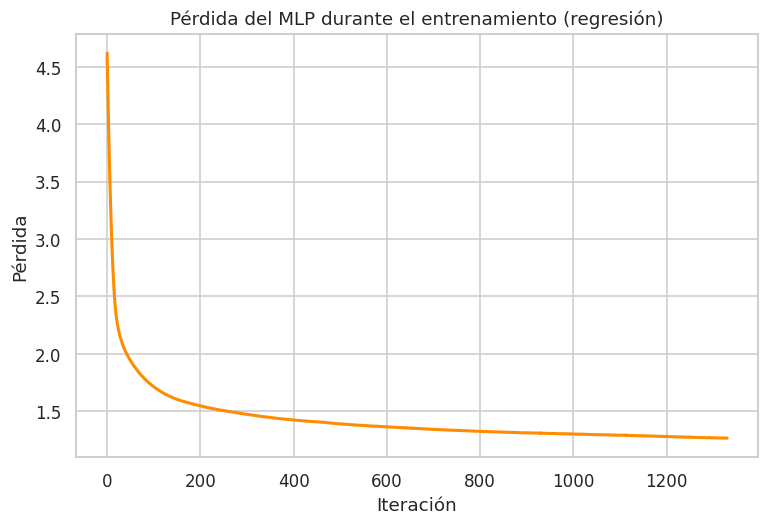

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(modelos_reg['MLP (10 neuronas)'].loss_curve_, color='darkorange', linewidth=2)
plt.title('Pérdida del MLP durante el entrenamiento (regresión)')
plt.xlabel('Iteración'); plt.ylabel('Pérdida')
plt.show()

**Análisis de la tabla de regresión.**

- **MSE, MAE y RMSE** miden el error promedio en unidades de `log1p(runtime)`; cuanto menores, mejor.
  RMSE penaliza más los errores grandes que MAE.
- **R²** indica la proporción de varianza del target explicada por el modelo. Un R² de 0 equivale a
  predecir siempre la media; valores mayores indican mejor ajuste.
- El **MLP** obtiene el mejor desempeño (R² ≈ 0,47), seguido de los modelos lineales regularizados
  (Lineal/Ridge/Lasso, R² ≈ 0,40–0,41). Esto es coherente con la no linealidad observada en la
  dispersión: una red neuronal con una capa oculta captura mejor las interacciones entre variables.
- El **árbol de decisión** rinde peor (R² ≈ 0,33). Un árbol único, sin límite de profundidad, tiende a
  sobreajustar el entrenamiento y a generalizar mal; además, un único árbol no combina varios árboles
  como haría un bosque.
- En conjunto, los R² son **moderados** (no cercanos a 1) porque el tiempo de ejecución de un
  algoritmo depende de factores no observados y de la propia complejidad del problema. Aun así, los
  cinco modelos superan la línea base (R² > 0), lo que confirma que las variables capturan señal real.

La curva de pérdida del MLP muestra cómo el error de entrenamiento desciende de forma estable durante
las iteraciones, señal de que el proceso de optimización converge adecuadamente.

# Ejercicio 4: Modelos de clasificación.

Se realiza una división **70 % entrenamiento / 30 % prueba** con `train_test_split` (estratificada
para conservar la proporción de clases) y se entrenan los cuatro modelos solicitados.

## Verificar balanceo de clases

In [23]:
print('Distribución de clases:')
print(yc_final.value_counts())
print('\nProporción:')
print((yc_final.value_counts(normalize=True) * 100).round(2))
print('\n> El dataset está DESBALANCEADO: la clase minoritaria (crash) es ~8.5%.')

Distribución de clases:
Class
0    494
1     46
Name: count, dtype: int64

Proporción:
Class
0    91.48
1     8.52
Name: proportion, dtype: float64

> El dataset está DESBALANCEADO: la clase minoritaria (crash) es ~8.5%.


## Estandarización y división de datos

In [24]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc_final, yc_final, test_size=0.30, random_state=RANDOM_STATE, stratify=yc_final)

scaler_c = StandardScaler().fit(Xc_train)
Xc_train_s = scaler_c.transform(Xc_train)
Xc_test_s = scaler_c.transform(Xc_test)

print('Entrenamiento (70%):', Xc_train.shape)
print('Prueba (30%)       :', Xc_test.shape)
print('Clases en train:', dict(yc_train.value_counts()))
print('Clases en test :', dict(yc_test.value_counts()))

Entrenamiento (70%): (378, 20)
Prueba (30%)       : (162, 20)
Clases en train: {0: np.int64(346), 1: np.int64(32)}
Clases en test : {0: np.int64(148), 1: np.int64(14)}


## Modelos y evaluación de métricas

In [25]:
def metricas_clasificacion(y_true, y_pred):
    return {'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, zero_division=0),
            'Recall': recall_score(y_true, y_pred, zero_division=0),
            'F1-score': f1_score(y_true, y_pred, zero_division=0)}

modelos_clf = {
    'Regresión logística': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'Árbol de decisión': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(),
    'MLP (10 neuronas)': MLPClassifier(hidden_layer_sizes=(10,), max_iter=3000,
                                       random_state=RANDOM_STATE),
}

resultados_clf = {}
predicciones = {}
for nombre, modelo in modelos_clf.items():
    modelo.fit(Xc_train_s, yc_train)
    pred = modelo.predict(Xc_test_s)
    predicciones[nombre] = pred
    resultados_clf[nombre] = metricas_clasificacion(yc_test, pred)

tabla_clf = pd.DataFrame(resultados_clf).T.round(4)
print('Métricas de clasificación (clase positiva = crash):')
display(tabla_clf)

Métricas de clasificación (clase positiva = crash):


,Accuracy,Precision,Recall,F1-score
Regresión logística,0.9198,0.6667,0.1429,0.2353
Árbol de decisión,0.8457,0.0769,0.0714,0.0741
KNN,0.9136,0.5000,0.0714,0.1250
MLP (10 neuronas),0.8827,0.3077,0.2857,0.2963


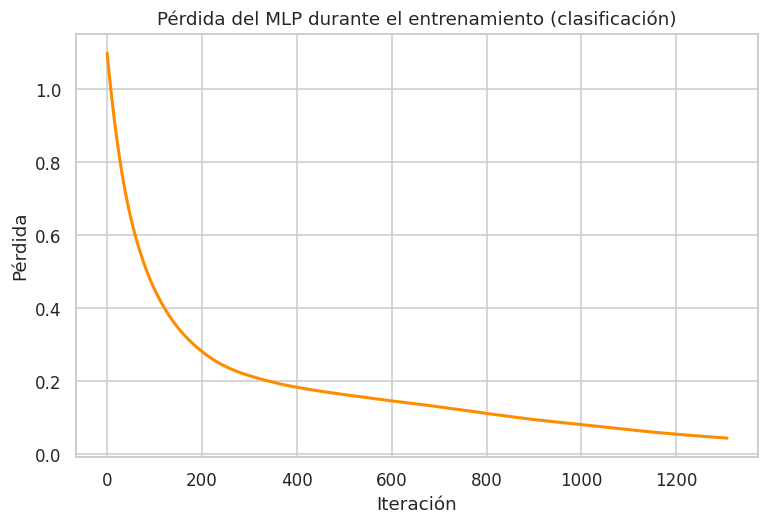

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(modelos_clf['MLP (10 neuronas)'].loss_curve_, color='darkorange', linewidth=2)
plt.title('Pérdida del MLP durante el entrenamiento (clasificación)')
plt.xlabel('Iteración'); plt.ylabel('Pérdida')
plt.show()

**Análisis de la tabla de clasificación.**

- **Accuracy**: proporción de aciertos totales. Es alta para todos los modelos (~0,85–0,93), pero
  **engaña** por el desbalance: predecir siempre "no crash" ya daría ~91 %.
- **Precision** (para "crash"): de los casos que el modelo marca como crash, cuántos lo son de verdad.
- **Recall** (para "crash"): de los crash reales, cuántos detecta el modelo.
- **F1-score**: media armónica de precisión y recall; es la métrica más útil con clases
  desbalanceadas.
- El **MLP** obtiene el mejor F1 (≈ 0,30), seguido de la regresión logística (≈ 0,24). El árbol y KNN
  quedan muy bajos (F1 < 0,13).
- La razón de fondo es el **desbalance** y el **solapamiento** de las clases visto en el Ejercicio 2:
  hay muy pocos casos de crash (46) y sus variables se parecen a las de no crash. Los modelos tienden
  a favorecer la clase mayoritaria, por lo que el recall de la clase minoritaria es bajo. Este es un
  resultado realista y frecuente en detección de fallos.
- El accuracy aparentemente alto **no** debe interpretarse como un buen modelo para el objetivo real,
  que es detectar los crash.

## Matriz de confusión del mejor modelo de clasificación

Mejor modelo según F1-score: MLP (10 neuronas)


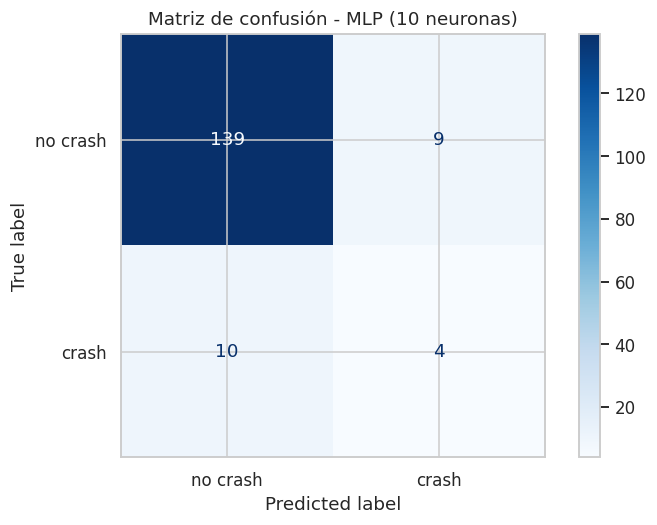

Matriz de confusión:
[[139   9]
 [ 10   4]]


In [27]:
mejor_modelo = tabla_clf['F1-score'].idxmax()
print('Mejor modelo según F1-score:', mejor_modelo)

cm = confusion_matrix(yc_test, predicciones[mejor_modelo])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no crash', 'crash'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Matriz de confusión - {mejor_modelo}')
plt.show()

print('Matriz de confusión:')
print(cm)

**Interpretación de la matriz de confusión.**
La matriz tiene la forma:

|                    | Pred: no crash | Pred: crash |
|--------------------|----------------|-------------|
| **Real: no crash** | TN             | FP          |
| **Real: crash**    | FN             | TP          |

- **TN (verdaderos negativos):** "no crash" correctamente clasificados. Son la gran mayoría.
- **FP (falsos positivos):** se predijo crash donde no lo había. Generan falsas alarmas.
- **FN (falsos negativos):** crash reales que el modelo no detectó. Suelen ser **el error más grave**
  en detección de fallos, porque significa dejar pasar una simulación que sí va a colapsar.
- **TP (verdaderos positivos):** crash detectados correctamente.

El mejor modelo acierta bien la clase mayoritaria pero **detecta pocos crash** (recall bajo),
reflejado en una columna/​fila con muchos falsos negativos. La matriz demuestra, mejor que el accuracy,
que el modelo prioriza la clase mayoritaria. **Limitación y posible mejora:** técnicas de
rebalanceo (pesos de clase, remuestreo) podrían aumentar el recall de la clase "crash", a costa de
más falsas alarmas.

# Ejercicio 5: Feedback.

> ⏳ **Pendiente.** Tome pantallazos de los comentarios realizados en el foro de la Tarea 2 al trabajo
> de un compañero de su grupo y adjúntelos aquí.
>
> _[Insertar imagen(es) del feedback realizado en el foro]_

# Referencias (normas APA)

- Tierney, K., & Malitsky, Y. (s. f.). *CPMP-2015-regression* [Conjunto de datos]. OpenML. https://www.openml.org/d/41700
- Lucas, D. D., Klein, R., Tannahill, J., Ivanova, D., Brandon, S., Domyancic, D., & Zhang, Y. (2013). Failure analysis of parameter-induced simulation crashes in climate models. *Geoscientific Model Development Discussions, 6*, 585–623.
- UCI Machine Learning Repository. (s. f.). *Climate Model Simulation Crashes Data Set*. University of California, Irvine.
- Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.
- Deepti, C., & Roopal, K. (2023). *Introduction to Machine Learning with Python*. Bentham Science Publishers.
- Colliot, O. (Ed.). (2023). *Machine learning for brain disorders* (Neuromethods, Vol. 197). Humana Press.
- Massaron, L., & Boschetti, A. (2016). *Regression Analysis with Python*. Packt Publishing.


---
*Documento elaborado como evidencia de la Tarea 2 – Componente práctico – Machine Learning (UNAD).*